In [4]:
!pip install mne

  **EEG Sleep Stage Classification — Full Pipeline
  Zekriyapanah Gashti & Farjamnia (2025) | arXiv:2510.07524**


  STEP 1 : Mount Drive & discover all SC4* PSG/Hypnogram pairs
  STEP 2 : Load + preprocess raw EDF → 30-second epochs
  STEP 3 : CWT (Morlet) feature extraction per frequency band
  STEP 4 : XGBoost classifier with 5-fold stratified CV
  STEP 5 : Evaluation + plots (scalograms, confusion matrix,
            feature importance)

  HOW TO USE IN GOOGLE COLAB:
    1. Copy this file into a Colab notebook (one cell or split)
    2. Set DATA_DIR below to your Drive folder path
    3. Runtime → Run all

In [5]:
# Imports
import os, glob, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt
import mne
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# 0.  CONFIGURATION  ← only change DATA_DIR

DATA_DIR = '/content/drive/MyDrive/Digilians/Queens/deep_learning/project/sleep-cassette'
OUT_DIR  = '/content/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

CHANNEL   = 'EEG Fpz-Cz'   # primary channel used in the paper
SFREQ     = 100             # resample target (Hz)
EPOCH_SEC = 30              # standard sleep epoch length

# Sleep stage label mapping  (AASM via Sleep-EDF annotations)
STAGE_MAP = {
    'Sleep stage W' : 0,
    'Sleep stage 1' : 1,
    'Sleep stage 2' : 2,
    'Sleep stage 3' : 3,
    'Sleep stage 4' : 3,   # N3 = SWS (merge 3+4 → N3, AASM)
    'Sleep stage R' : 4,
    'Sleep stage ?' : -1,  # unknown → excluded
    'Movement time' : -1,  # movement → excluded
}
STAGE_NAMES = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
COLORS      = {0:'#E24B4A', 1:'#EF9F27', 2:'#378ADD',
               3:'#1D9E75', 4:'#7F77DD'}

# CWT / frequency band settings
WAVELET    = 'morl'
FREQ_BANDS = {
    'delta' : (0.5,  4.0),
    'theta' : (4.0,  8.0),
    'alpha' : (8.0, 13.0),
    'sigma' : (12.0,15.0),
    'beta'  : (13.0,30.0),
}


In [13]:
# DISCOVER ALL PSG / HYPNOGRAM PAIRS

print(" Discovering EDF file pairs")

# PSG files:        SC4??1E0-PSG.edf  (or SC4??2E0-PSG.edf)
# Hypnogram files:  SC4??1EH-Hypnogram.edf
psg_files  = sorted(glob.glob(os.path.join(DATA_DIR, '*-PSG.edf')))
hyp_files  = sorted(glob.glob(os.path.join(DATA_DIR, '*-Hypnogram.edf')))

def subject_id(path):
    """Extract subject/night code, e.g. SC4011 from SC4011E0-PSG.edf"""
    fname = os.path.basename(path)
    # Take first 6 characters: SC + 4-digit code
    return fname[:6]

# Build a dict: subject_id → (psg_path, hyp_path)
psg_dict = {subject_id(p): p for p in psg_files}
hyp_dict = {subject_id(h): h for h in hyp_files}

pairs = []
for sid in sorted(psg_dict.keys()):
    if sid in hyp_dict:
        pairs.append((sid, psg_dict[sid], hyp_dict[sid]))
    else:
        print(f"No hypnogram found for {sid}, skipping")

print(f"\n  Found {len(pairs)} matched PSG–Hypnogram pairs:")
for sid, psg, hyp in pairs:
    print(f"    {sid}  →  {os.path.basename(psg)}"
          f"  +  {os.path.basename(hyp)}")

 Discovering EDF file pairs

  Found 76 matched PSG–Hypnogram pairs:
    SC4001  →  SC4001E0-PSG.edf  +  SC4001EC-Hypnogram.edf
    SC4002  →  SC4002E0-PSG.edf  +  SC4002EC-Hypnogram.edf
    SC4011  →  SC4011E0-PSG.edf  +  SC4011EH-Hypnogram.edf
    SC4012  →  SC4012E0-PSG.edf  +  SC4012EC-Hypnogram.edf
    SC4021  →  SC4021E0-PSG.edf  +  SC4021EH-Hypnogram.edf
    SC4022  →  SC4022E0-PSG.edf  +  SC4022EJ-Hypnogram.edf
    SC4031  →  SC4031E0-PSG.edf  +  SC4031EC-Hypnogram.edf
    SC4032  →  SC4032E0-PSG.edf  +  SC4032EP-Hypnogram.edf
    SC4041  →  SC4041E0-PSG.edf  +  SC4041EC-Hypnogram.edf
    SC4042  →  SC4042E0-PSG.edf  +  SC4042EC-Hypnogram.edf
    SC4051  →  SC4051E0-PSG.edf  +  SC4051EC-Hypnogram.edf
    SC4052  →  SC4052E0-PSG.edf  +  SC4052EC-Hypnogram.edf
    SC4061  →  SC4061E0-PSG.edf  +  SC4061EC-Hypnogram.edf
    SC4062  →  SC4062E0-PSG.edf  +  SC4062EC-Hypnogram.edf
    SC4071  →  SC4071E0-PSG.edf  +  SC4071EC-Hypnogram.edf
    SC4072  →  SC4072E0-PSG.edf  +  SC4072EH-H

In [14]:
#  LOAD + PREPROCESS ALL PAIRS → EPOCHS

print(" \n Loading & epoching raw EDF files")


def load_psg_hypnogram(psg_path, hyp_path,
                       channel=CHANNEL, sfreq=SFREQ,
                       epoch_sec=EPOCH_SEC,
                       wake_buffer_epochs=60):
    """
    Load one PSG + Hypnogram EDF pair.
    Load one PSG + Hypnogram pair with full preprocessing.

    Pipeline:
      1. Load EDF, pick Fpz-Cz channel
      2. Resample to sfreq (100 Hz)
      3. Bandpass filter 0.5–40 Hz
      4. Build label array — epochs never covered by any annotation → -1
      5. Trim excessive Wake: keep wake_buffer_epochs on each side of sleep
         Wake epochs INSIDE the sleep period are preserved as-is
      6. Drop all epochs with label == -1 (unknown / unannotated / movement)

    Returns
    -------
    epochs : np.ndarray  shape (n_valid, n_samples)  float32  — µV
    labels : np.ndarray  shape (n_valid,)            int  0-4, -1 excluded

    Wake trimming
    -------------
    Keeps wake_buffer_epochs (default 60 = 30 min) of Wake before the
    first and after the last non-Wake sleep epoch. Wake epochs that
    appear INSIDE the sleep period (arousals) are preserved as-is.
    Only epochs labelled -1 (movement / unknown / unannotated) are dropped.
    """
    # ── Load PSG ──────────────────────────────────────────
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)

    # Pick the Fpz-Cz channel (primary channel in the paper)
    if channel not in raw.ch_names:
        eeg_chs = [c for c in raw.ch_names if 'EEG' in c.upper()]
        if not eeg_chs:
            raise ValueError(f"Channel '{channel}' not found in "
                             f"{psg_path}. Available: {raw.ch_names}")
        channel = eeg_chs[0]
        print(f" Falling back to channel: {channel}")

    raw.pick_channels([channel])

    # Resample to SFREQ (100 Hz)
    if raw.info['sfreq'] != sfreq:
        raw.resample(sfreq, npad='auto')

    # Band-pass filter 0.5 – 40 Hz (standard preprocessing)
    raw.filter(0.5, 40.0, fir_window='hamming', verbose=False)

    data = raw.get_data()[0] * 1e6    # → µV, shape: (n_samples_total,)

    # ── Load Hypnogram annotations ────────────────────────
    ann = mne.read_annotations(hyp_path)

    # Build label array aligned to 30-second epochs
    n_samples_per_epoch = int(epoch_sec * sfreq)
    n_epochs_total      = len(data) // n_samples_per_epoch

    # Fill label array (default -1 = unknown/unannotated)
    label_arr = np.full(n_epochs_total, -1, dtype=np.int32)

    for onset, duration, description in zip(
            ann.onset, ann.duration, ann.description):
        stage = STAGE_MAP.get(description, -1)
        start_epoch = int(onset // epoch_sec)
        n_ep        = max(1, int(round(duration / epoch_sec)))
        for ep in range(start_epoch, min(start_epoch + n_ep,
                                         n_epochs_total)):
            label_arr[ep] = stage

    # ── Trim excessive Wake ───────────────────────────────
    # Boundaries defined by first/last N1/N2/N3/REM epoch.
    # Everything between those boundaries is kept intact,
    # including any Wake arousals mid-recording.
    sleep_mask   = (label_arr >= 1) & (label_arr <= 4)
    sleep_epochs = np.where(sleep_mask)[0]

    if len(sleep_epochs) == 0:
        print(f"  [warn] No sleep epochs found, skipping {psg_path}")
        return (np.empty((0, n_samples_per_epoch), dtype=np.float32),
                np.empty((0,), dtype=np.int32))

    sleep_start = sleep_epochs[0]
    sleep_end   = sleep_epochs[-1]

    trim_start = max(0, sleep_start - wake_buffer_epochs)
    trim_end   = min(n_epochs_total, sleep_end + wake_buffer_epochs + 1)

    label_arr = label_arr[trim_start : trim_end]
    data      = data[trim_start * n_samples_per_epoch :
                     trim_end   * n_samples_per_epoch]

    # ── Slice into 30-second epochs ───────────────────────
    # label == -1 covers: movement, '?', and unannotated gaps.
    # Wake (0) is intentionally kept.
    n_trimmed   = len(label_arr)
    epochs_list = []
    labels_list = []
    for i in range(n_trimmed):
        lbl = label_arr[i]
        if lbl == -1:
            continue                  # skip unknown/movement/unannotated
        segment = data[i * n_samples_per_epoch :
                       (i + 1) * n_samples_per_epoch]
        epochs_list.append(segment)
        labels_list.append(lbl)

    return (np.array(epochs_list, dtype=np.float32),
            np.array(labels_list, dtype=np.int32))


# Load all pairs
all_epochs, all_labels, all_sids = [], [], []

for idx, (sid, psg_path, hyp_path) in enumerate(pairs):
    print(f"\n  [{idx+1}/{len(pairs)}] Loading {sid} ...", end=' ')
    try:
        ep, lb = load_psg_hypnogram(psg_path, hyp_path)

        if len(ep) == 0:
            print("  skipped (no valid epochs)")
            continue

        all_epochs.append(ep)
        all_labels.append(lb)
        # one subject ID per epoch — same length as ep
        all_sids.append(np.array([sid] * len(ep)))

        stage_counts = {STAGE_NAMES[s]: int((lb==s).sum())
                        for s in range(5) if (lb==s).sum() > 0}
        print(f"{len(ep)} epochs  →  {stage_counts}")
    except Exception as e:
        print(f"\n    ✗ Error: {e}")

epochs = np.concatenate(all_epochs, axis=0)
labels = np.concatenate(all_labels, axis=0)
sids   = np.concatenate(all_sids,   axis=0)   # shape: (n_epochs,)  dtype: str

print(f"\n  ─────────────────────────────────────────────")
print(f"  Total epochs : {epochs.shape}  "
      f"(shape: n_epochs × {epochs.shape[1]} samples)")
print(f"  Total labels : {labels.shape}")
print(f"  Total sids   : {sids.shape}  —  {len(np.unique(sids))} unique subjects")
print(f"  Class distribution:")
for s in range(5):
    cnt = (labels == s).sum()
    pct = 100 * cnt / len(labels)
    print(f"    {STAGE_NAMES[s]:5s} (class {s}): "
          f"{cnt:5d}  ({pct:.1f}%)")

# Save preprocessed arrays
np.save(os.path.join(OUT_DIR, 'epochs.npy'), epochs)
np.save(os.path.join(OUT_DIR, 'labels.npy'), labels)
np.save(os.path.join(OUT_DIR, 'sids.npy'),   sids)
print(f"\n  Saved preprocessed data → {OUT_DIR}")

 
 Loading & epoching raw EDF files

  [1/76] Loading SC4001 ... 841 epochs  →  {'Wake': 188, 'N1': 58, 'N2': 250, 'N3': 220, 'REM': 125}

  [2/76] Loading SC4002 ... 1127 epochs  →  {'Wake': 183, 'N1': 59, 'N2': 373, 'N3': 297, 'REM': 215}

  [3/76] Loading SC4011 ... 1103 epochs  →  {'Wake': 157, 'N1': 109, 'N2': 562, 'N3': 105, 'REM': 170}

  [4/76] Loading SC4012 ... 1186 epochs  →  {'Wake': 162, 'N1': 92, 'N2': 660, 'N3': 96, 'REM': 176}

  [5/76] Loading SC4021 ... 1025 epochs  →  {'Wake': 128, 'N1': 94, 'N2': 545, 'N3': 95, 'REM': 163}

  [6/76] Loading SC4022 ... 1009 epochs  →  {'Wake': 125, 'N1': 184, 'N2': 402, 'N3': 119, 'REM': 179}

  [7/76] Loading SC4031 ... 952 epochs  →  {'Wake': 140, 'N1': 61, 'N2': 485, 'N3': 57, 'REM': 209}

  [8/76] Loading SC4032 ... 911 epochs  →  {'Wake': 136, 'N1': 45, 'N2': 400, 'N3': 131, 'REM': 199}

  [9/76] Loading SC4041 ... 1235 epochs  →  {'Wake': 200, 'N1': 166, 'N2': 620, 'N3': 53, 'REM': 196}

  [10/76] Loading SC4042 ... 1200 epochs

In [18]:
#   CWT FEATURE EXTRACTION

from scipy.signal import welch

print(" \n STEP 3 — CWT Feature Extraction (Morlet wavelet)")


def compute_cwt_features(epoch, sfreq=SFREQ, wavelet=WAVELET):
    """
    Apply CWT to one 30-s epoch and extract statistical features
    per EEG frequency band.

    Features per band (8 stats × 5 bands = 40):
      mean, std, energy, spectral-entropy,
      skewness, kurtosis, max, min

    Time-domain features (8):
      zero-crossing rate, RMS, mean-absolute-value,
      waveform length, log-variance,
      Hjorth activity, mobility, complexity

    Frequency-domain features (4):
      relative spectral power — delta, theta, alpha, beta  (Welch PSD)

    Total: 40 + 8 + 4 = 52 features per epoch
    """
    dt           = 1.0 / sfreq
    central_freq = pywt.central_frequency(wavelet)

    # Scales covering 0.5 – 30 Hz
    scale_max = central_freq / (0.5  * dt)
    scale_min = central_freq / (30.0 * dt)
    scales    = np.geomspace(scale_min, scale_max, num=64)

    coeffs, freqs = pywt.cwt(epoch, scales, wavelet,
                             sampling_period=dt)
    power = np.abs(coeffs) ** 2          # (64, n_time)

    features = []

    # ── Per-band CWT statistical features (40) ────────────
    for band_name, (flo, fhi) in FREQ_BANDS.items():
        mask = (freqs >= flo) & (freqs <= fhi)
        if mask.sum() == 0:
            features.extend([0.0] * 8)
            continue

        band_power = power[mask, :].mean(axis=0)   # (n_time,)
        bp_sum     = band_power.sum() + 1e-12

        features.extend([
            np.mean(band_power),
            np.std(band_power),
            np.sum(band_power),                     # energy
            -np.sum((band_power / bp_sum) *
                    np.log(band_power / bp_sum + 1e-12)),  # entropy
            float(stats.skew(band_power)),
            float(stats.kurtosis(band_power)),
            np.max(band_power),
            np.min(band_power),
        ])

    # ── Time-domain features (8) ──────────────────────────
    d1       = np.diff(epoch)
    d2       = np.diff(d1)
    activity = np.var(epoch)

    features.extend([
        ((np.diff(np.sign(epoch)) != 0).sum()) / len(epoch),  # ZCR
        np.sqrt(np.mean(epoch ** 2)),                          # RMS
        np.mean(np.abs(epoch)),                                # MAV
        np.sum(np.abs(d1)),                                    # waveform length
        np.log(activity + 1e-12),                             # log-variance
        # ── Hjorth parameters (paper section 3.3.i) ───────
        activity,                                              # activity
        np.sqrt(np.var(d1) / (activity      + 1e-12)),        # mobility
        (np.sqrt(np.var(d2) / (np.var(d1)   + 1e-12)) /
         (np.sqrt(np.var(d1) / (activity    + 1e-12)) + 1e-12)),  # complexity
    ])

    # ── Frequency-domain relative spectral power (4) ──────
    # Welch PSD — independent from CWT, pure frequency-domain estimate
    freqs_w, psd = welch(epoch, fs=sfreq, nperseg=sfreq * 4)
    total_power  = psd.sum() + 1e-12
    for flo, fhi in FREQ_BANDS.values():
        mask_w = (freqs_w >= flo) & (freqs_w <= fhi)
        features.append(psd[mask_w].sum() / total_power)      # relative power

    return np.array(features, dtype=np.float32)


# ── Feature names (for importance plot) ───────────────────
feature_names = []
for band in FREQ_BANDS:
    for stat in ['mean', 'std', 'energy', 'entropy',
                 'skew', 'kurt', 'max', 'min']:
        feature_names.append(f'{band}_{stat}')

feature_names += [
    'zcr', 'rms', 'mav', 'wl', 'log_var',          # time-domain
    'hjorth_activity', 'hjorth_mobility',             # Hjorth
    'hjorth_complexity',
]
feature_names += [f'{band}_relpower' for band in FREQ_BANDS]  # Welch

assert len(feature_names) == 53, f"Expected 53, got {len(feature_names)}"

print(f"  Extracting features from {len(epochs)} epochs "
      f"({len(feature_names)} features each)...")
print(f"  (CWT is O(scales × n_time) — expect ~1 min per 800 epochs)")

X_features = []
for i, epoch in enumerate(epochs):
    if i % 50 == 0:
        print(f"    {i}/{len(epochs)} epochs processed...", end='\r')
    X_features.append(compute_cwt_features(epoch))

X      = np.array(X_features)
y      = labels.copy()
groups = sids.copy()       # patient ID per epoch — for GroupShuffleSplit

print(f"\n  Feature matrix : {X.shape}  ✓")
print(f"  Labels         : {y.shape}  ✓")
print(f"  Groups (sids)  : {groups.shape}  — {len(np.unique(groups))} unique subjects  ✓")

# Save so you can skip re-extraction on future runs
np.save(os.path.join(OUT_DIR, 'X_features.npy'), X)
np.save(os.path.join(OUT_DIR, 'y_labels.npy'),   y)
np.save(os.path.join(OUT_DIR, 'groups_sids.npy'), groups)
print(f"  Saved features → {OUT_DIR}")

 
 STEP 3 — CWT Feature Extraction (Morlet wavelet)
  Extracting features from 88387 epochs (53 features each)...
  (CWT is O(scales × n_time) — expect ~1 min per 800 epochs)

  Feature matrix : (88387, 53)  ✓
  Labels         : (88387,)  ✓
  Groups (sids)  : (88387,)  — 76 unique subjects  ✓
  Saved features → /content/outputs



  Generating CWT scalogram plot...


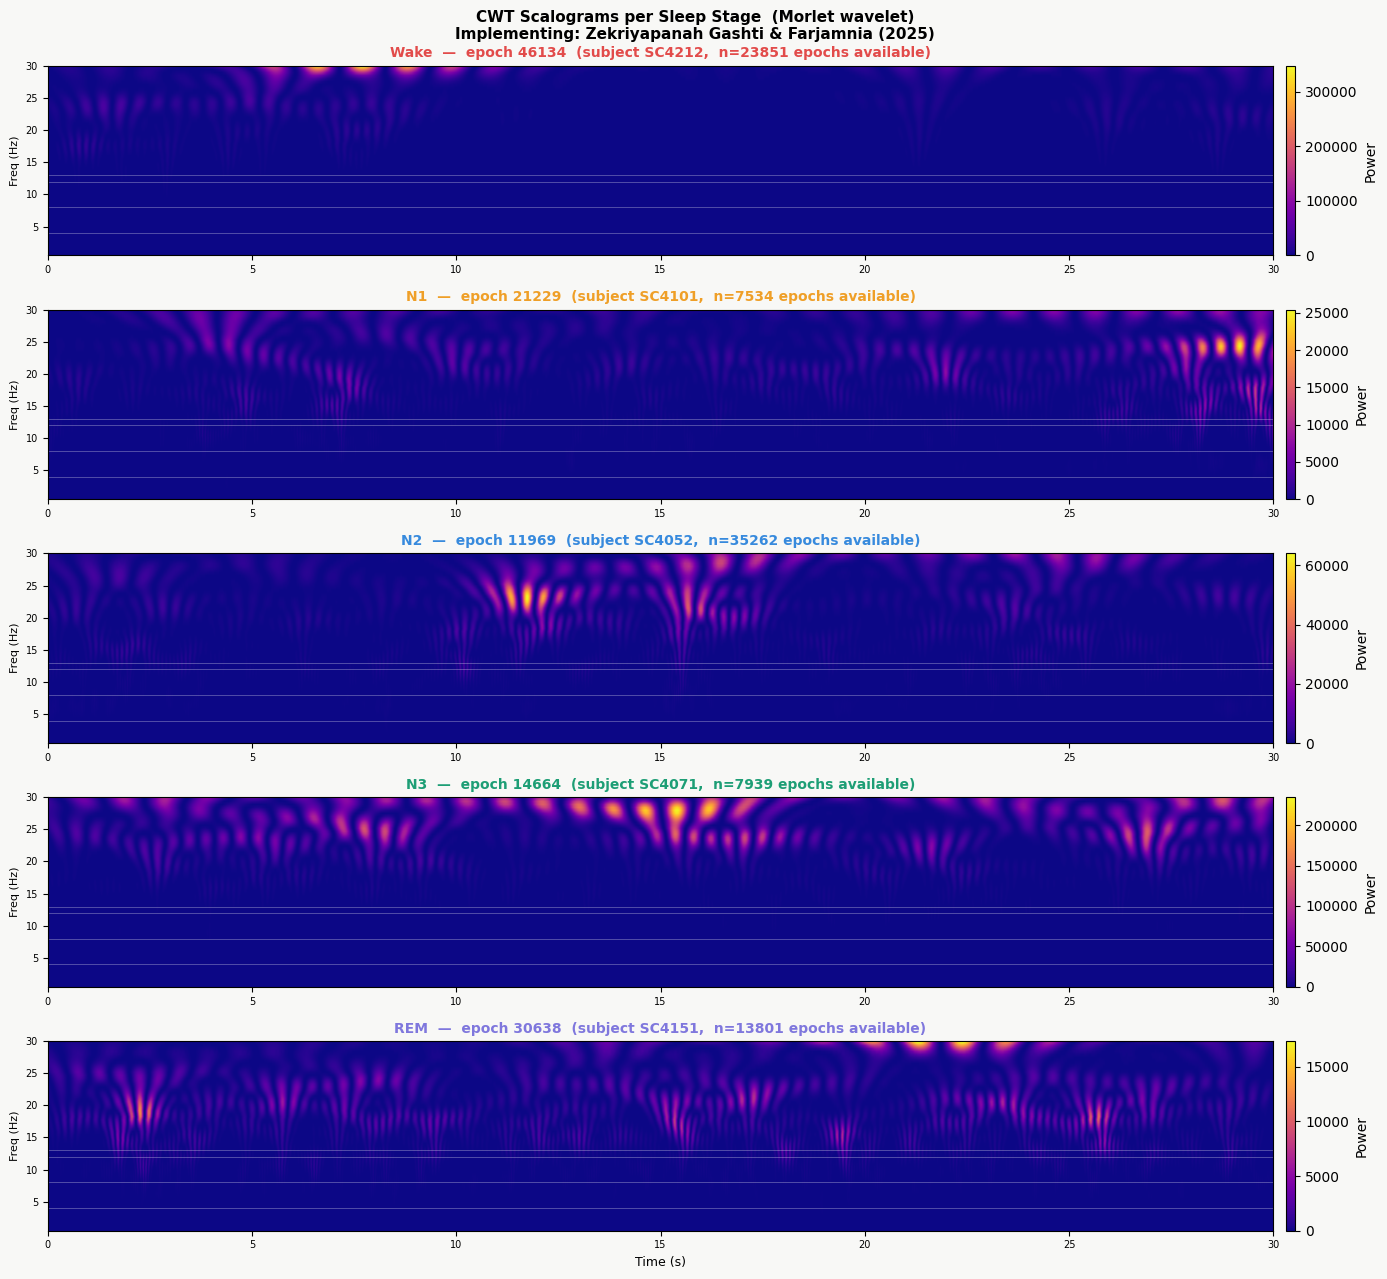

  Saved → /content/outputs/03a_cwt_scalograms.png


In [20]:
# ─────────────────────────────────────────────────────────
# 4.  CWT SCALOGRAM VISUALISATION (one per stage)
# ─────────────────────────────────────────────────────────
print("\n  Generating CWT scalogram plot...")

dt      = 1.0 / SFREQ
central = pywt.central_frequency(WAVELET)
scales  = np.geomspace(central / (30.0 * dt),
                       central / (0.5  * dt), num=64)

fig, axes = plt.subplots(5, 1, figsize=(14, 13))
fig.patch.set_facecolor('#f8f8f6')

for ax, stage in zip(axes, range(5)):
    # Pick the median-energy epoch for this stage — more representative
    # than [0] which may be a noisy boundary epoch
    stage_idxs = np.where(y == stage)[0]

    if len(stage_idxs) == 0:
        ax.set_title(f'{STAGE_NAMES[stage]} — no epochs found',
                     fontsize=10, color='gray')
        ax.axis('off')
        continue

    stage_epochs  = epochs[stage_idxs].astype(float)
    energies      = np.sum(stage_epochs ** 2, axis=1)
    median_pos    = np.argmin(np.abs(energies - np.median(energies)))
    idx           = stage_idxs[median_pos]
    ep            = epochs[idx].astype(float)
    subject_id    = groups[idx]           # which patient this epoch came from

    coeffs, freqs = pywt.cwt(ep, scales, WAVELET,
                             sampling_period=dt)
    power = np.abs(coeffs) ** 2

    im = ax.imshow(
        power, aspect='auto', origin='lower',
        extent=[0, EPOCH_SEC, freqs[-1], freqs[0]],
        cmap='plasma', interpolation='bilinear'
    )
    ax.set_ylabel('Freq (Hz)', fontsize=8)
    ax.set_title(
        f'{STAGE_NAMES[stage]}  —  epoch {idx}  (subject {subject_id},  '
        f'n={len(stage_idxs)} epochs available)',
        fontsize=10, fontweight='bold', color=COLORS[stage]
    )
    ax.tick_params(labelsize=7)
    for flo, _ in FREQ_BANDS.values():
        ax.axhline(flo, color='white', linewidth=0.4, alpha=0.5)
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label='Power')

axes[-1].set_xlabel('Time (s)', fontsize=9)
fig.suptitle(
    'CWT Scalograms per Sleep Stage  (Morlet wavelet)\n'
    'Implementing: Zekriyapanah Gashti & Farjamnia (2025)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, '03a_cwt_scalograms.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  Saved → {out_path}")

Checking the nan and inf values

In [21]:
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

print(f"Number of NaN values in X: {nan_count}")
print(f"Number of infinite values in X: {inf_count}")

if nan_count == 0 and inf_count == 0:
    print("No non-finite values found in X.")
else:
    print("Non-finite values detected. They need to be handled before scaling.")

Number of NaN values in X: 0
Number of infinite values in X: 0
No non-finite values found in X.


In [ ]:
# Replace NaN values with the mean of their respective columns
# Also replace inf values with NaN first, then handle all NaNs
X_cleaned = X.copy()
X_cleaned[np.isinf(X_cleaned)] = np.nan

for i in range(X_cleaned.shape[1]):
    col_mean = np.nanmean(X_cleaned[:, i])
    # Only replace if the mean is a finite number, otherwise, replace with 0 or a sensible default
    if np.isfinite(col_mean):
        X_cleaned[:, i] = np.nan_to_num(X_cleaned[:, i], nan=col_mean, posinf=col_mean, neginf=col_mean)
    else:
        # If the whole column is NaN/inf, replace with 0
        X_cleaned[:, i] = np.nan_to_num(X_cleaned[:, i], nan=0.0, posinf=0.0, neginf=0.0)

# Verify that there are no more non-finite values
final_nan_count = np.isnan(X_cleaned).sum()
final_inf_count = np.isinf(X_cleaned).sum()
print(f"After cleaning: NaN count = {final_nan_count}, Inf count = {final_inf_count}")

# X_new = X_cleaned # Update X to the cleaned version


After cleaning: NaN count = 0, Inf count = 0


Train test spilt the data 80:20

In [22]:
# spliting the data to 80:20
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Load saved features
X      = np.load(os.path.join(OUT_DIR, 'X_features.npy'))
y      = np.load(os.path.join(OUT_DIR, 'y_labels.npy'))
sids   = np.load(os.path.join(OUT_DIR, 'groups_sids.npy'))

# ── Train/Test split — group-aware (no subject leakage) ──
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=sids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"  Train: {len(train_idx)} epochs  —  {len(np.unique(sids[train_idx]))} subjects")
print(f"  Test : {len(test_idx)} epochs  —  {len(np.unique(sids[test_idx]))} subjects")


  Train: 70350 epochs  —  60 subjects
  Test : 18037 epochs  —  16 subjects


Z-score standarization for dataset

In [23]:
# ── Z-score standardisation ───────────────────────────────
# Fit ONLY on train → transform both train and test
# Prevents data leakage from test distribution into training
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform
X_test  = scaler.transform(X_test)        # transform only ✓

print(f"\n  After standardisation:")
print(f"    X_train mean ≈ {X_train.mean():.4f}  std ≈ {X_train.std():.4f}")
print(f"    X_test  mean ≈ {X_test.mean():.4f}  std ≈ {X_test.std():.4f}")

# Save for later use
np.save(os.path.join(OUT_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(OUT_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(OUT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(OUT_DIR, 'y_test.npy'),  y_test)

import joblib
joblib.dump(scaler, os.path.join(OUT_DIR, 'scaler.pkl'))  # save for inference
print(f"\n  Saved splits + scaler → {OUT_DIR}")


  After standardisation:
    X_train mean ≈ 0.0000  std ≈ 1.0000
    X_test  mean ≈ -0.0112  std ≈ 0.9653

  Saved splits + scaler → /content/outputs


K-fold cross validation

In [24]:
# XGBoost CLASSIFIER  (5-fold stratified CV)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import xgboost as xgb

print("\n XGBoost Training (5-fold CV on train set)")


# Load the properly split + scaled data from previous step
X_train = np.load(os.path.join(OUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUT_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(OUT_DIR, 'y_test.npy'))

# ── Class weights to handle imbalance (Wake >> N1) ────────
class_counts  = np.bincount(y_train)
class_weights = len(y_train) / (len(np.unique(y_train)) * class_counts)
sample_weights = np.array([class_weights[yi] for yi in y_train])

# ── XGBoost model ─────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'mlogloss',
    use_label_encoder= False,
    random_state     = 42,
    n_jobs           = -1,
)

# ── 5-fold CV on train set only ───────────────────────────
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_preds = np.zeros_like(y_train)
fold_accs = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr,  X_val = X_train[tr_idx], X_train[val_idx]
    y_tr,  y_val = y_train[tr_idx], y_train[val_idx]
    sw_tr        = sample_weights[tr_idx]

    xgb_model.fit(X_tr, y_tr, sample_weight=sw_tr, verbose=False)

    preds              = xgb_model.predict(X_val)
    all_preds[val_idx] = preds
    fold_acc           = accuracy_score(y_val, preds)
    fold_accs.append(fold_acc)
    print(f"  Fold {fold+1}/5  →  accuracy: {fold_acc:.4f}")

print(f"\n  Mean CV accuracy : {np.mean(fold_accs):.4f}")
print(f"  Std  CV accuracy : {np.std(fold_accs):.4f}")


 XGBoost Training (5-fold CV on train set)
  Fold 1/5  →  accuracy: 0.8011
  Fold 2/5  →  accuracy: 0.8080
  Fold 3/5  →  accuracy: 0.7974
  Fold 4/5  →  accuracy: 0.8003
  Fold 5/5  →  accuracy: 0.8020

  Mean CV accuracy : 0.8018
  Std  CV accuracy : 0.0035


Test model

In [28]:
# ── Final model — retrain on full train set ───────────────
print("\n  Retraining on full training set...")
xgb_model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)



  Retraining on full training set...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [29]:
# ── Evaluate on held-out test set ────────────────────────
y_pred     = xgb_model.predict(X_test)
test_acc   = accuracy_score(y_test, y_pred)
print(f"  Test accuracy    : {test_acc:.4f}")

  Test accuracy    : 0.7945


Resultt for test

In [30]:
print("\n RESULTS")

# CV performance (on train set)
cv_acc      = accuracy_score(y_train, all_preds)
cv_macro_f1 = f1_score(y_train, all_preds, average='macro')

# Test performance (on held-out test set)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"\n  ── Cross-Validation (train set) ──")
print(f"  CV mean ± std    : {np.mean(fold_accs)*100:.2f}% ± {np.std(fold_accs)*100:.2f}%")
print(f"  CV Accuracy      : {cv_acc*100:.2f}%")
print(f"  CV Macro F1      : {cv_macro_f1*100:.2f}%")

print(f"\n  ── Held-out Test Set ──")
print(f"  Test Accuracy    : {test_acc*100:.2f}%")
print(f"  Test Macro F1    : {test_macro_f1*100:.2f}%")

print(f"\n  ── Paper Benchmark ──")
print(f"  Accuracy : 88.37%   |   Macro F1 : 73.15%")

target_names = [STAGE_NAMES[s] for s in sorted(np.unique(y_test))]
print(f"\n  Per-class report (test set):")
print(classification_report(y_test, y_pred,
                             target_names=target_names, digits=4))


 RESULTS

  ── Cross-Validation (train set) ──
  CV mean ± std    : 80.18% ± 0.35%
  CV Accuracy      : 80.18%
  CV Macro F1      : 75.76%

  ── Held-out Test Set ──
  Test Accuracy    : 79.45%
  Test Macro F1    : 72.49%

  ── Paper Benchmark ──
  Accuracy : 88.37%   |   Macro F1 : 73.15%

  Per-class report (test set):
              precision    recall  f1-score   support

        Wake     0.9440    0.8864    0.9143      5290
          N1     0.2975    0.4287    0.3513      1234
          N2     0.8756    0.7896    0.8304      6879
          N3     0.7658    0.8906    0.8235      1975
         REM     0.6883    0.7225    0.7050      2659

    accuracy                         0.7945     18037
   macro avg     0.7142    0.7436    0.7249     18037
weighted avg     0.8165    0.7945    0.8030     18037



CONFUSION MATRIX for cross Validation

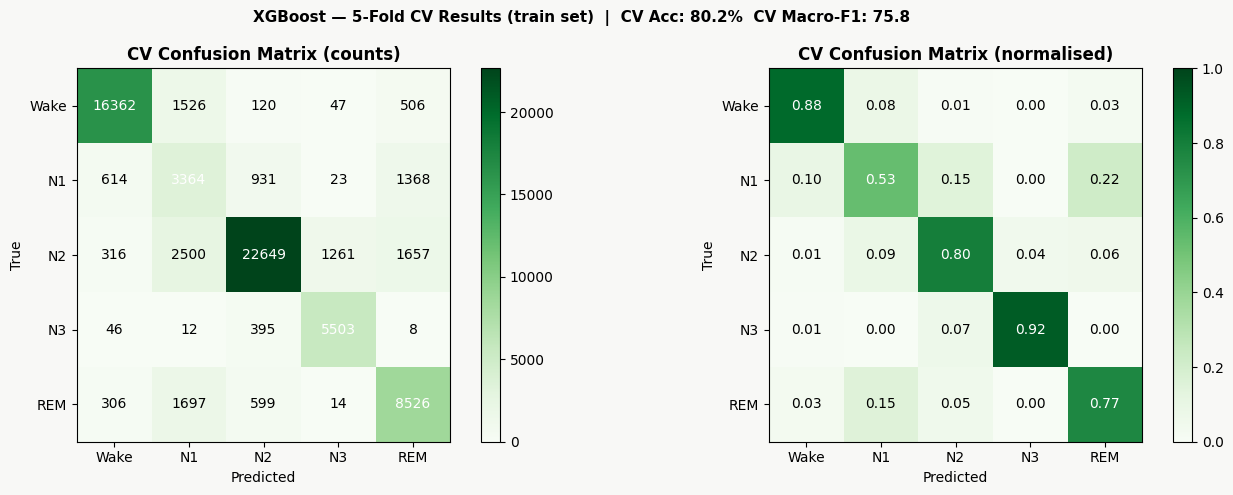

  CV Accuracy  : 80.18%
  CV Macro-F1  : 75.76%
  Saved → /content/outputs/03a_confusion_matrix_cv.png


In [35]:
from matplotlib.patches import Patch

# ── CONFUSION MATRIX — Cross-Validation (train set) ──────
cm_cv      = confusion_matrix(y_train, all_preds)
cm_cv_norm = cm_cv.astype(float) / cm_cv.sum(axis=1, keepdims=True)

target_names = [STAGE_NAMES[s] for s in sorted(np.unique(y_train))]

def fmt_counts(v): return str(int(v))
def fmt_norm(v):   return f'{v:.2f}'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

for ax, data, title, fmt in zip(
        axes,
        [cm_cv,       cm_cv_norm],
        ['CV Confusion Matrix (counts)', 'CV Confusion Matrix (normalised)'],
        [fmt_counts,  fmt_norm]):

    vmax = 1.0 if data is cm_cv_norm else None
    im   = ax.imshow(data, cmap='Greens', vmin=0, vmax=vmax)  # ← Oranges to distinguish from test

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(target_names)))
    ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(j, i,
                    fmt(data[i, j]),
                    ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_cv_norm[i, j] > 0.5 else 'black')

    plt.colorbar(im, ax=ax)

# CV metrics
cv_acc      = accuracy_score(y_train, all_preds)
cv_macro_f1 = f1_score(y_train, all_preds, average='macro')

fig.suptitle(
    f'XGBoost — 5-Fold CV Results (train set)  |  '
    f'CV Acc: {cv_acc*100:.1f}%  CV Macro-F1: {cv_macro_f1*100:.1f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

out_path = os.path.join(OUT_DIR, '03a_confusion_matrix_cv.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  CV Accuracy  : {cv_acc*100:.2f}%")
print(f"  CV Macro-F1  : {cv_macro_f1*100:.2f}%")
print(f"  Saved → {out_path}")

CONFUSION MATRIX for test

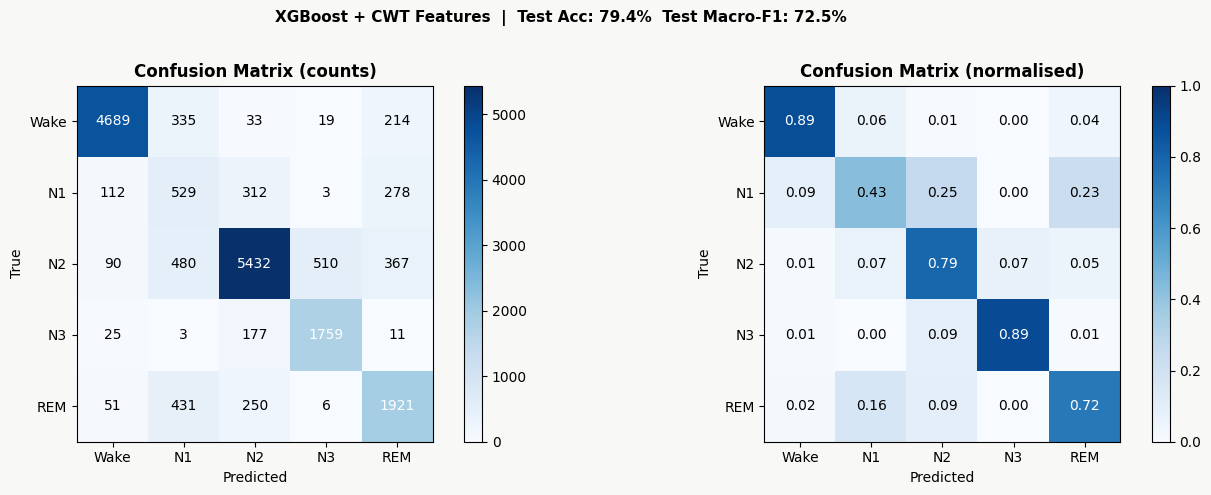

  Saved → /content/outputs/03b_confusion_matrix.png


In [32]:
# ── CONFUSION MATRIX PLOT ─────────────────────────────────

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#f8f8f6')

def fmt_counts(v):  return str(int(v))
def fmt_norm(v):    return f'{v:.2f}'

for ax, data, title, fmt in zip(
        axes,
        [cm,            cm_norm],
        ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)'],
        [fmt_counts,    fmt_norm]):

    vmax = 1.0 if data is cm_norm else None
    im   = ax.imshow(data, cmap='Blues', vmin=0, vmax=vmax)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(len(target_names)))
    ax.set_yticks(range(len(target_names)))
    ax.set_xticklabels(target_names)
    ax.set_yticklabels(target_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

    for i in range(len(target_names)):
        for j in range(len(target_names)):
            ax.text(j, i,
                    fmt(data[i, j]),          # ← uses correct fmt per matrix
                    ha='center', va='center',
                    fontsize=10,
                    color='white' if cm_norm[i, j] > 0.5 else 'black')

    plt.colorbar(im, ax=ax)

fig.suptitle(
    f'XGBoost + CWT Features  |  '
    f'Test Acc: {test_acc*100:.1f}%  '
    f'Test Macro-F1: {test_macro_f1*100:.1f}%\n',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
out_path = os.path.join(OUT_DIR, '03b_confusion_matrix.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  Saved → {out_path}")

feature importance for test

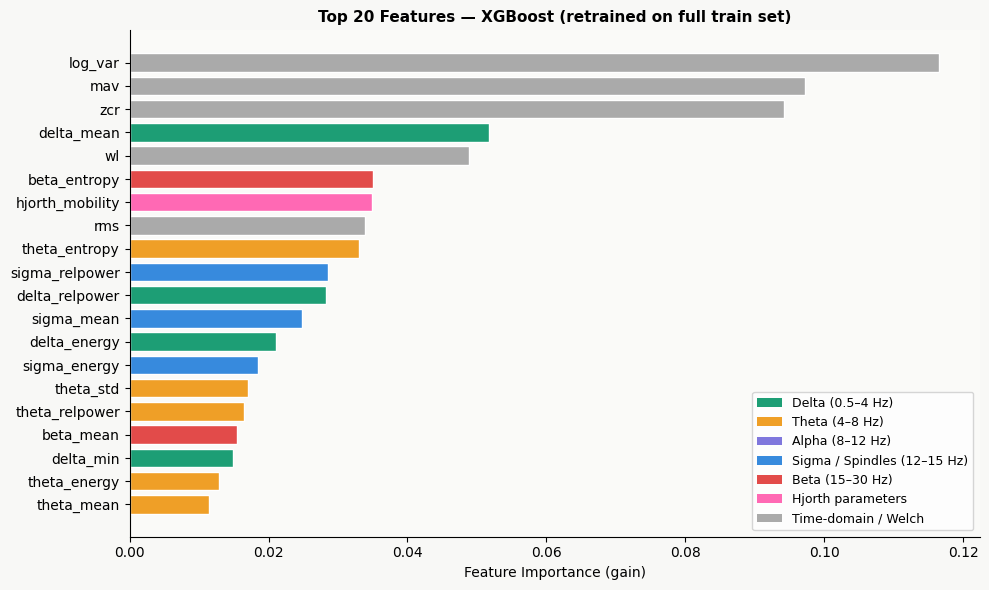

  Saved → /content/outputs/03c_feature_importance.png


In [33]:
# FEATURE IMPORTANCE PLOT

from matplotlib.patches import Patch

# ── FEATURE IMPORTANCE PLOT ───────────────────────────────
importances = xgb_model.feature_importances_
top_k   = 20
top_idx = np.argsort(importances)[-top_k:][::-1]

# ← extended color map to cover all feature types
feature_colors = {
    # CWT band features
    'delta' : '#1D9E75',
    'theta' : '#EF9F27',
    'alpha' : '#7F77DD',
    'sigma' : '#378ADD',
    'beta'  : '#E24B4A',
    # Time-domain features
    'zcr'            : '#aaaaaa',
    'rms'            : '#aaaaaa',
    'mav'            : '#aaaaaa',
    'wl'             : '#aaaaaa',
    'log'            : '#aaaaaa',   # log_var → prefix 'log'
    'hjorth'         : '#FF69B4',   # hjorth_* → prefix 'hjorth'
    'variance'       : '#aaaaaa',
    'skewness'       : '#aaaaaa',
    'kurtosis'       : '#aaaaaa',
}

def get_color(name):
    prefix = name.split('_')[0]
    return feature_colors.get(prefix, '#cccccc')

bar_colors = [get_color(feature_names[i]) for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f8f6')
ax.barh(
    [feature_names[i] for i in top_idx],
    importances[top_idx],
    color=bar_colors, edgecolor='white'
)
ax.set_xlabel('Feature Importance (gain)', fontsize=10)
ax.set_title(f'Top {top_k} Features — XGBoost (retrained on full train set)',
             fontsize=11, fontweight='bold')
ax.set_facecolor('#fafaf8')
ax.spines[['top', 'right']].set_visible(False)
ax.invert_yaxis()

legend_elements = [
    Patch(facecolor=c, label=l) for c, l in [
        ('#1D9E75', 'Delta (0.5–4 Hz)'),
        ('#EF9F27', 'Theta (4–8 Hz)'),
        ('#7F77DD', 'Alpha (8–12 Hz)'),
        ('#378ADD', 'Sigma / Spindles (12–15 Hz)'),
        ('#E24B4A', 'Beta (15–30 Hz)'),
        ('#FF69B4', 'Hjorth parameters'),
        ('#aaaaaa', 'Time-domain / Welch'),
    ]
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()

out_path = os.path.join(OUT_DIR, '03c_feature_importance.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"  Saved → {out_path}")

In [ ]:
# save the model
import joblib
joblib.dump(xgb_model, os.path.join(OUT_DIR, 'xgb_model.pkl'))
print(f"\n  Saved model → {OUT_DIR}")

In [ ]:
# SAVE FEATURES (for reuse in deep learning step)

np.save(os.path.join(OUT_DIR, 'X_cwt_features.npy'), X)
np.save(os.path.join(OUT_DIR, 'y_labels.npy'), y)

print("\n" + "=" * 58)
print("  DONE")
print(f"  All outputs saved to:\n  {OUT_DIR}")
print("=" * 58)